In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv
/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv


In [3]:
# ============================================================
# IMPORTIMI I BIBLIOTEKAVE
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.under_sampling import RandomUnderSampler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

print("Bibliotekat u importuan me sukses.")

Bibliotekat u importuan me sukses.


In [4]:
# ============================================================
# NGARKIMI I DATASET-IT
# ============================================================

print("===== NGARKIMI I DATASET-IT =====")

# Path drejt dataset-it të muajit tetor
oct_path = "/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv"

# Numri i regjistrimeve që do të përdoren
N_ROWS = 6_000_000

# Leximi i dataset-it në pjesë për të shmangur ngarkimin
# e të gjitha 42+ milionë regjistrimeve në memorie
chunks = []
rows_loaded = 0

for chunk in pd.read_csv(
    oct_path,
    chunksize=500_000
):
    
    remaining = N_ROWS - rows_loaded
    
    if len(chunk) <= remaining:
        chunks.append(chunk)
        rows_loaded += len(chunk)
    else:
        chunks.append(chunk.iloc[:remaining])
        rows_loaded += remaining
    
    if rows_loaded >= N_ROWS:
        break

# Bashkimi i pjesëve të përzgjedhura
df = pd.concat(
    chunks,
    ignore_index=True
)

# Lirimi i hapsirës së përdorur nga pjesët e përkohshme
del chunks

print("\n===== DATASET-I U NGARKUA ME SUKSES =====")
print("Forma e dataset-it:", df.shape)
print("Numri i regjistrimeve:", f"{df.shape[0]:,}")
print("Numri i kolonave:", df.shape[1])

print("\n===== 5 REGJISTRIMET E PARA =====")
display(df.head())

===== NGARKIMI I DATASET-IT =====

===== DATASET-I U NGARKUA ME SUKSES =====
Forma e dataset-it: (6000000, 9)
Numri i regjistrimeve: 6,000,000
Numri i kolonave: 9

===== 5 REGJISTRIMET E PARA =====


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [5]:
# ============================================================
# ANALIZA E TË DHËNAVE EKSPLORUESE
# ============================================================

print("===== ANALIZA E TË DHËNAVE EKSPLORUESE =====")

# ------------------------------------------------------------
# FORMA E DATASET-IT
# ------------------------------------------------------------

print("\n===== FORMA E DATASET-IT =====")

print("Number of rows    :", f"{df.shape[0]:,}")
print("Number of columns :", df.shape[1])


# ------------------------------------------------------------
# 5 REGJISTRIMET E PARA
# ------------------------------------------------------------

print("\n===== 5 REGJISTRIMET E PARA =====")

display(df.head())


# ------------------------------------------------------------
# INFORMACIONET E DATASET-IT
# ------------------------------------------------------------

print("\n===== INFORMACIONET E DATASET-IT =====")

df.info()

===== ANALIZA E TË DHËNAVE EKSPLORUESE =====

===== FORMA E DATASET-IT =====
Number of rows    : 6,000,000
Number of columns : 9

===== 5 REGJISTRIMET E PARA =====


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d



===== INFORMACIONET E DATASET-IT =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000000 entries, 0 to 5999999
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 412.0+ MB


In [8]:
# ============================================================
# STATISTIKAT PËRSHKRUESE
# ============================================================

print("===== STATISTIKAT PËRSHKRUESE =====")

display(df.describe())

===== STATISTIKAT PËRSHKRUESE =====


,product_id,category_id,price,user_id
count,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06
mean,9.856941e+06,2.056491e+18,2.986332e+02,5.314491e+08
std,1.110506e+07,1.634106e+16,3.661892e+02,1.698568e+07
min,1.001588e+06,2.053014e+18,0.000000e+00,1.835035e+08
25%,1.005115e+06,2.053014e+18,6.667000e+01,5.155535e+08
50%,4.804055e+06,2.053014e+18,1.668000e+02,5.270588e+08
75%,1.520011e+07,2.053014e+18,3.704100e+02,5.483944e+08
max,5.560001e+07,2.175420e+18,2.574070e+03,5.571017e+08


In [9]:
# ============================================================
# VLERA QË MUNGOJNË
# ============================================================

print("===== VLERA QË MUNGOJNË =====")

missing_values = pd.DataFrame({
    "Vlerat që mungojnë": df.isnull().sum(),
    "Përqindja": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing_values)

===== VLERA QË MUNGOJNË =====


,Vlerat që mungojnë,Përqindja
event_time,0,0.00
event_type,0,0.00
product_id,0,0.00
category_id,0,0.00
category_code,1858828,30.98
brand,822626,13.71
price,0,0.00
user_id,0,0.00
user_session,0,0.00


In [10]:
# ============================================================
# REGJISTRIMET E DYFISHTA
# ============================================================

print("===== REGJISTRIMET E DYFISHTA =====")

duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Numri i regjistrimeve të dyfishta :", f"{duplicate_count:,}")
print("Përqindja e regjistrimeve të dyfishta     :", f"{duplicate_percentage:.2f}%")

===== REGJISTRIMET E DYFISHTA =====
Numri i regjistrimeve të dyfishta : 3,779
Përqindja e regjistrimeve të dyfishta     : 0.06%


In [11]:
# ============================================================
#  SHPËRNDARJA E LLOJEVE TË NDËRVEPRIMIT
# ============================================================

print("=====  SHPËRNDARJA E LLOJEVE TË NDËRVEPRIMIT =====")

event_distribution = pd.DataFrame({
    "Numri": df["event_type"].value_counts(),
    "Përqindja": (
        df["event_type"].value_counts(normalize=True) * 100
    ).round(2)
})

display(event_distribution)

=====  SHPËRNDARJA E LLOJEVE TË NDËRVEPRIMIT =====


,Numri,Përqindja
event_type,,
view,5768080,96.13
cart,127027,2.12
purchase,104893,1.75


In [12]:
# ============================================================
# HEQJA E REGJISTRIMEVE TË DYFISHTA
# ============================================================

print("===== HEQJA E REGJISTRIMEVE TË DYFISHTA =====")

before_duplicates = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after_duplicates = len(df)

removed_duplicates = before_duplicates - after_duplicates

print("Regjistrimet para heqjes së dublikatave :", f"{before_duplicates:,}")
print("Regjistrimet e dyfishta të hequra             :", f"{removed_duplicates:,}")
print("Regjistrimet pas heqjes së dublikatave  :", f"{after_duplicates:,}")

===== HEQJA E REGJISTRIMEVE TË DYFISHTA =====
Regjistrimet para heqjes së dublikatave : 6,000,000
Regjistrimet e dyfishta të hequra             : 3,779
Regjistrimet pas heqjes së dublikatave  : 5,996,221


In [13]:
# ============================================================
# TRAJTIMI I VLERAVE QË MUNGOJNË
# ============================================================

print("===== TRAJTIMI I VLERAVE QË MUNGOJNË =====")

df["brand"] = df["brand"].fillna("unknown")
df["category_code"] = df["category_code"].fillna("unknown")

print("\nVlerat që mungojnë pas zëvendësimit:")
print(df[["brand", "category_code"]].isna().sum())

===== TRAJTIMI I VLERAVE QË MUNGOJNË =====

Vlerat që mungojnë pas zëvendësimit:
brand            0
category_code    0
dtype: int64


===== SHPËRNDARJA E LLOJEVE TË NDËRVEPRIMIT PAS PASTRIMIT =====


,Numri,Përqindja
event_type,,
view,5767752,96.19
cart,123581,2.06
purchase,104888,1.75


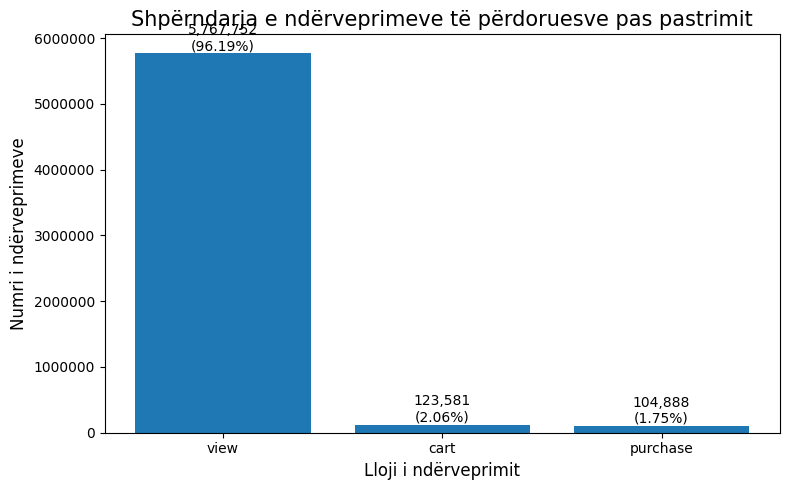

In [14]:
# ============================================================
# SHPËRNDARJA E LLOJEVE TË NDËRVEPRIMIT PAS PASTRIMIT
# ============================================================

print("===== SHPËRNDARJA E LLOJEVE TË NDËRVEPRIMIT PAS PASTRIMIT =====")

event_counts_clean = df["event_type"].value_counts()
event_percentages_clean = (
    df["event_type"].value_counts(normalize=True) * 100
).round(2)

event_distribution_clean = pd.DataFrame({
    "Numri": event_counts_clean,
    "Përqindja": event_percentages_clean
})

display(event_distribution_clean)

# ============================================================
# PARAQITJA GRAFIKE
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    event_distribution_clean.index,
    event_distribution_clean["Numri"]
)

plt.title(
    "Shpërndarja e ndërveprimeve të përdoruesve pas pastrimit",
    fontsize=15
)

plt.xlabel("Lloji i ndërveprimit", fontsize=12)
plt.ylabel("Numri i ndërveprimeve", fontsize=12)

plt.ticklabel_format(
    axis="y",
    style="plain"
)

for bar, percentage in zip(
    bars,
    event_distribution_clean["Përqindja"]
):
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Figure_1_Shperndarja_Nderveprimeve_Pas_Pastrimit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# ============================================================
# KONVERTIMI I KOHËS SË NDËRVEPRIMIT
# ============================================================

print("===== KONVERTIMI I KOHËS SË NDËRVEPRIMIT =====")

df["event_time"] = pd.to_datetime(
    df["event_time"],
    utc=True
)

print("Tipi i të dhënave të event_time:", df["event_time"].dtype)
print("Koha e ndërveprimit të parë:", df["event_time"].min())
print("Koha e ndërveprimit të fundit :", df["event_time"].max())

===== KONVERTIMI I KOHËS SË NDËRVEPRIMIT =====
Tipi i të dhënave të event_time: datetime64[ns, UTC]
Koha e ndërveprimit të parë: 2019-10-01 00:00:00+00:00
Koha e ndërveprimit të fundit : 2019-10-05 16:25:48+00:00


In [16]:
# ============================================================
# RENDITJA KRONOLOGJIKE
# ============================================================

print("===== RENDITJA KRONOLOGJIKE =====")

df = df.sort_values(
    ["user_session", "event_time"],
    kind="stable"
).reset_index(drop=True)

print("Koha e ndërveprimit të parë:", df["event_time"].min())
print("Koha e ndërveprimit të fundit :", df["event_time"].max())

# Kontrolli i renditjes kronologjike brenda çdo sesioni të përdoruesit
chronological_check = (
    df.groupby("user_session")["event_time"]
      .apply(lambda x: x.is_monotonic_increasing)
      .all()
)

print(
    "Renditja kronologjike brenda sesioneve:",
    chronological_check
)

===== RENDITJA KRONOLOGJIKE =====
Koha e ndërveprimit të parë: 2019-10-01 00:00:00+00:00
Koha e ndërveprimit të fundit : 2019-10-05 16:25:48+00:00
Renditja kronologjike brenda sesioneve: True


In [17]:
# ============================================================
# KODIMI I LLOJEVE TË NDËRVEPRIMIT
# ============================================================

print("===== KODIMI I LLOJEVE TË NDËRVEPRIMIT =====")

event_mapping = {
    "view": 0,
    "cart": 1,
    "purchase": 2
}

df["event_code"] = df["event_type"].map(event_mapping)

print("\nEvent mapping:")
for event, code in event_mapping.items():
    print(f"{event} -> {code}")

print("\nHarta e kodimit të ndërveprimeve:")
print(df["event_code"].value_counts().sort_index())

print("\nShpërndarja e ndërveprimeve pas kodimit:", df["event_code"].isna().sum())

===== KODIMI I LLOJEVE TË NDËRVEPRIMIT =====

Event mapping:
view -> 0
cart -> 1
purchase -> 2

Harta e kodimit të ndërveprimeve:
event_code
0    5767752
1     123581
2     104888
Name: count, dtype: int64

Shpërndarja e ndërveprimeve pas kodimit: 0


In [18]:
# ============================================================
# ANALIZA E SESIONEVE TË PËRDORUESVE
# ============================================================

print("===== ANALIZA E SESIONEVE TË PËRDORUESVE =====")

number_of_sessions = df["user_session"].nunique()

print("Numri i sesioneve unike:", f"{number_of_sessions:,}")

session_lengths = df.groupby("user_session").size()

print("\nStatistikat e gjatësisë së sesioneve:")
print(session_lengths.describe())

print("\nSesione me të paktën 6 ndërveprime:",
      (session_lengths >= 6).sum())

===== ANALIZA E SESIONEVE TË PËRDORUESVE =====
Numri i sesioneve unike: 1,289,469

Statistikat e gjatësisë së sesioneve:
count    1.289469e+06
mean     4.650147e+00
std      6.731473e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      6.880000e+02
dtype: float64

Sesione me të paktën 6 ndërveprime: 309428


In [19]:
# ============================================================
# KRIJIMI I TË DHËNAVE SEKUENCIALE
# ============================================================

SEQUENCE_LENGTH = 5

print("===== KRIJIMI I SEKUENCAVE =====")
print("Gjatësia e sekuencës:", SEQUENCE_LENGTH)
print("Detyra e parashikimit: 5 ndërveprime të mëparshme -> ndërveprimi pasues")

# Numri i sekuencave të mundshme
valid_sessions = session_lengths[session_lengths >= SEQUENCE_LENGTH + 1]

total_sequences = (
    valid_sessions - SEQUENCE_LENGTH
).sum()

print("Sesione të disponueshme për krijimin e sekuencave:",
      f"{len(valid_sessions):,}")

print("Numri total i sekuencave të mundshme:",
      f"{total_sequences:,}")

===== KRIJIMI I SEKUENCAVE =====
Gjatësia e sekuencës: 5
Detyra e parashikimit: 5 ndërveprime të mëparshme -> ndërveprimi pasues
Sesione të disponueshme për krijimin e sekuencave: 309,428
Numri total i sekuencave të mundshme: 2,360,318


In [20]:
# ============================================================
# NDËRTIMI I TË DHËNAVE SEKUENCIALE
# ============================================================

print("===== NDËRTIMI I SEKUENCAVE =====")

SEQUENCE_LENGTH = 5

X_sequences = np.empty(
    (total_sequences, SEQUENCE_LENGTH),
    dtype=np.int8
)

y_sequences = np.empty(
    total_sequences,
    dtype=np.int8
)

target_times = np.empty(
    total_sequences,
    dtype="datetime64[ns]"
)

sequence_index = 0

for session_id, group in df.groupby("user_session", sort=False):

    events = group["event_code"].to_numpy(dtype=np.int8)
    times = group["event_time"].dt.tz_localize(None).to_numpy(
        dtype="datetime64[ns]"
    )

    session_length = len(events)

    if session_length <= SEQUENCE_LENGTH:
        continue

    number_of_sequences = session_length - SEQUENCE_LENGTH

    end_index = sequence_index + number_of_sequences

    for i in range(number_of_sequences):

        X_sequences[
            sequence_index + i
        ] = events[i:i + SEQUENCE_LENGTH]

        y_sequences[
            sequence_index + i
        ] = events[i + SEQUENCE_LENGTH]

        target_times[
            sequence_index + i
        ] = times[i + SEQUENCE_LENGTH]

    sequence_index = end_index


print("\n===== SEKUENCAT U KRIJUAN =====")

print("Forma e X :", X_sequences.shape)
print("Forma e y :", y_sequences.shape)
print("Forma e kohëve të synuara:", target_times.shape)

print("\nSekuencat e pritshme:",
      f"{total_sequences:,}")

print("Sekuencat e krijuara:",
      f"{sequence_index:,}")

===== NDËRTIMI I SEKUENCAVE =====

===== SEKUENCAT U KRIJUAN =====
Forma e X : (2360318, 5)
Forma e y : (2360318,)
Forma e kohëve të synuara: (2360318,)

Sekuencat e pritshme: 2,360,318
Sekuencat e krijuara: 2,360,318


In [22]:
 # ============================================================
# VALIDIMI I SEKUENCAVE
# ============================================================

print("===== VALIDIMI I SEKUENCAVE =====")

# ------------------------------------------------------------
# FORMATET BAZË
# ------------------------------------------------------------

print("\n===== FORMATET BAZË =====")
print("Forma e X:", X_sequences.shape)
print("Forma e y:", y_sequences.shape)

# ------------------------------------------------------------
# 10 SEKUENCAT E PARA
# ------------------------------------------------------------

print("\n===== 10 SEKUENCAT E PARA =====")

for i in range(10):
    print(
        f"Sekuenca {i+1}: "
        f"{X_sequences[i].tolist()} -> Objektivi: {y_sequences[i]}"
    )

# ------------------------------------------------------------
# SHPËRNDARJA E OBJEKTIVIT
# ------------------------------------------------------------

print("\n===== SHPËRNDARJA E OBJEKTIVIT =====")

target_counts = pd.Series(
    y_sequences
).value_counts().sort_index()

target_distribution = pd.DataFrame({
    "Ndërveprimi": ["view", "cart", "purchase"],
    "Kodi": [0, 1, 2],
    "Numri": [
        target_counts.get(0, 0),
        target_counts.get(1, 0),
        target_counts.get(2, 0)
    ]
})

target_distribution["Përqindja"] = (
    target_distribution["Numri"]
    / len(y_sequences)
    * 100
).round(2)

display(target_distribution)

# ------------------------------------------------------------
# RENDITJA KRONOLOGJIKE E KOHËVE TË OBJEKTIVIT
# ------------------------------------------------------------

print("\n===== RENDITJA E KOHËVE TË OBJEKTIVIT =====")

chronological_targets = (
    np.all(target_times[:-1] <= target_times[1:])
)

print(
    "Kohët e objektivit janë në rend kronologjik:",
    chronological_targets
)

print("Koha e parë e objektivit:", target_times[0])
print("Koha e fundit e objektivit:", target_times[-1])

# ------------------------------------------------------------
# INTERVALI KOHOR I OBJEKTIVAVE
# ------------------------------------------------------------

print("\n===== INTERVALI KOHOR I OBJEKTIVAVE =====")

print(
    "Periudha e objektivave:",
    target_times[0],
    "->",
    target_times[-1]
)

# ------------------------------------------------------------
# PËRMBLEDHJA E VALIDIMIT TË SEKUENCAVE
# ------------------------------------------------------------

print("\n===== PËRMBLEDHJA E VALIDIMIT =====")

print(
    "Gjatësia e saktë e sekuencës:",
    X_sequences.shape[1] == SEQUENCE_LENGTH
)

print(
    "Përputhja e mostrave X/y:",
    X_sequences.shape[0] == y_sequences.shape[0]
)

print(
    "Pa objektiva që mungojnë:",
    not np.isnan(y_sequences).any()
)

print(
    "Renditja kronologjike e objektivave:",
    chronological_targets
)

print("\n===== VALIDIMI I SEKUENCAVE PËRFUNDOI =====")

===== VALIDIMI I SEKUENCAVE =====

===== FORMATET BAZË =====
Forma e X: (2360318, 5)
Forma e y: (2360318,)

===== 10 SEKUENCAT E PARA =====
Sekuenca 1: [0, 0, 0, 0, 0] -> Objektivi: 0
Sekuenca 2: [0, 0, 0, 0, 0] -> Objektivi: 0
Sekuenca 3: [0, 0, 0, 0, 0] -> Objektivi: 0
Sekuenca 4: [0, 0, 0, 0, 0] -> Objektivi: 0
Sekuenca 5: [0, 0, 0, 0, 0] -> Objektivi: 0
Sekuenca 6: [0, 0, 0, 0, 0] -> Objektivi: 0
Sekuenca 7: [0, 0, 0, 0, 0] -> Objektivi: 0
Sekuenca 8: [0, 0, 0, 0, 0] -> Objektivi: 0
Sekuenca 9: [0, 0, 0, 0, 0] -> Objektivi: 0
Sekuenca 10: [0, 0, 0, 0, 0] -> Objektivi: 0

===== SHPËRNDARJA E OBJEKTIVIT =====


,Ndërveprimi,Kodi,Numri,Përqindja
0,view,0,2278353,96.53
1,cart,1,43274,1.83
2,purchase,2,38691,1.64



===== RENDITJA E KOHËVE TË OBJEKTIVIT =====
Kohët e objektivit janë në rend kronologjik: False
Koha e parë e objektivit: 2019-10-02T17:11:35.000000000
Koha e fundit e objektivit: 2019-10-03T18:24:19.000000000

===== INTERVALI KOHOR I OBJEKTIVAVE =====
Periudha e objektivave: 2019-10-02T17:11:35.000000000 -> 2019-10-03T18:24:19.000000000

===== PËRMBLEDHJA E VALIDIMIT =====
Gjatësia e saktë e sekuencës: True
Përputhja e mostrave X/y: True
Pa objektiva që mungojnë: True
Renditja kronologjike e objektivave: False

===== VALIDIMI I SEKUENCAVE PËRFUNDOI =====


In [23]:
# ============================================================
# RENDITJA KRONOLOGJIKE E SEKUENCAVE
# ============================================================

print("===== RENDITJA KRONOLOGJIKE E SEKUENCAVE =====")

# Përcaktimi i rendit kronologjik bazuar në kohën e objektivit
sequence_order = np.argsort(target_times)

# Rirenditja e sekuencave, objektivave dhe kohëve të objektivit
X_sequences = X_sequences[sequence_order]
y_sequences = y_sequences[sequence_order]
target_times = target_times[sequence_order]

print("\n===== RENDITJA KRONOLOGJIKE PËRFUNDOI =====")

print("Koha e parë e objektivit:", target_times[0])
print("Koha e fundit e objektivit :", target_times[-1])

# Verifikimi i renditjes kronologjike
chronological_targets = np.all(
    target_times[:-1] <= target_times[1:]
)

print(
    "Kohët e objektivit janë në rend kronologjik:",
    chronological_targets
)

===== RENDITJA KRONOLOGJIKE E SEKUENCAVE =====

===== RENDITJA KRONOLOGJIKE PËRFUNDOI =====
Koha e parë e objektivit: 2019-10-01T00:02:41.000000000
Koha e fundit e objektivit : 2019-10-05T16:25:48.000000000
Kohët e objektivit janë në rend kronologjik: True


In [24]:
# ============================================================
# NDARJA KRONOLOGJIKE E TË DHËNAVE NË TRAJNIM / TESTIM
# NDARJA SIPAS KOHËS SË OBJEKTIVIT
# ============================================================

print("===== NDARJA KRONOLOGJIKE E TË DHËNAVE NË TRAJNIM / TESTIM =====")

# ------------------------------------------------------------
# Kohët e objektivit janë tashmë të renditura në mënyrë kronologjike
# ------------------------------------------------------------

n_sequences = len(X_sequences)

# Pozicioni i synuar për ndarjen në 80%
desired_split_index = int(n_sequences * 0.80)

# Përcaktimi i kohës së objektivit rreth kufirit të synuar prej 80%
split_time = target_times[desired_split_index]

# ------------------------------------------------------------
# E RËNDËSISHME:
# Të gjitha sekuencat me të njëjtën kohë objektivi
# mbeten në të njëjtin grup të të dhënave.
# ------------------------------------------------------------

train_mask = target_times < split_time
test_mask = target_times >= split_time

# ------------------------------------------------------------
# Krijimi i grupeve të trajnimit dhe testimit
# ------------------------------------------------------------

X_train = X_sequences[train_mask]
X_test = X_sequences[test_mask]

y_train = y_sequences[train_mask]
y_test = y_sequences[test_mask]

target_times_train = target_times[train_mask]
target_times_test = target_times[test_mask]

# ------------------------------------------------------------
# REZULTATET
# ------------------------------------------------------------

print("\n===== REZULTATET E NDARJES =====")

print("Numri total i sekuencave:", n_sequences)
print("Sekuencat për trajnim    :", len(X_train))
print("Sekuencat për testim     :", len(X_test))

print("\nForma e X_train:", X_train.shape)
print("Forma e X_test :", X_test.shape)

print("\nForma e y_train:", y_train.shape)
print("Forma e y_test :", y_test.shape)

# ------------------------------------------------------------
# KUFIJTË KOHORË
# ------------------------------------------------------------

print("\n===== KUFIJTË KOHORË =====")

print("Koha e ndarjes             :", split_time)

print(
    "Koha e parë e objektivit të trajnimit:",
    target_times_train[0]
)

print(
    "Koha e fundit e objektivit të trajnimit:",
    target_times_train[-1]
)

print(
    "Koha e parë e objektivit të testimit:",
    target_times_test[0]
)

print(
    "Koha e fundit e objektivit të testimit:",
    target_times_test[-1]
)

# ------------------------------------------------------------
# KONTROLLI KRONOLOGJIK
# ------------------------------------------------------------

train_chronological = np.all(
    target_times_train[:-1] <= target_times_train[1:]
)

test_chronological = np.all(
    target_times_test[:-1] <= target_times_test[1:]
)

# Ndarje e rreptë kohore
no_temporal_overlap = (
    target_times_train[-1] < target_times_test[0]
)

# ------------------------------------------------------------
# PËRQINDJET E NDARJES
# ------------------------------------------------------------

train_percentage = (
    len(X_train) / n_sequences * 100
)

test_percentage = (
    len(X_test) / n_sequences * 100
)

# ------------------------------------------------------------
# VALIDIMI
# ------------------------------------------------------------

print("\n===== KONTROLLI KRONOLOGJIK =====")

print(
    "Renditja kronologjike e trajnimit:",
    train_chronological
)

print(
    "Renditja kronologjike e testimit :",
    test_chronological
)

print(
    "Pa mbivendosje kohore:",
    no_temporal_overlap
)

print("\n===== PËRQINDJET E NDARJES =====")

print(
    f"Përqindja e trajnimit: {train_percentage:.2f}%"
)

print(
    f"Përqindja e testimit : {test_percentage:.2f}%"
)

# ------------------------------------------------------------
# VALIDIMI PËRFUNDIMTAR
# ------------------------------------------------------------

split_valid = (
    train_chronological
    and test_chronological
    and no_temporal_overlap
    and len(X_train) + len(X_test) == n_sequences
    and len(X_train) == len(y_train)
    and len(X_test) == len(y_test)
)

print("\n===== VALIDIMI I NDARJES TRAJNIM / TESTIM =====")

print(
    "Të gjitha sekuencat janë ruajtur:",
    len(X_train) + len(X_test) == n_sequences
)

print(
    "Përputhja X/y në trajnim:",
    len(X_train) == len(y_train)
)

print(
    "Përputhja X/y në testim:",
    len(X_test) == len(y_test)
)

print(
    "Ndarja kohore është e vlefshme:",
    split_valid
)

print("\n===== NDARJA E TË DHËNAVE NË TRAJNIM / TESTIM PËRFUNDOI =====")

===== NDARJA KRONOLOGJIKE E TË DHËNAVE NË TRAJNIM / TESTIM =====

===== REZULTATET E NDARJES =====
Numri total i sekuencave: 2360318
Sekuencat për trajnim    : 1888253
Sekuencat për testim     : 472065

Forma e X_train: (1888253, 5)
Forma e X_test : (472065, 5)

Forma e y_train: (1888253,)
Forma e y_test : (472065,)

===== KUFIJTË KOHORË =====
Koha e ndarjes             : 2019-10-04T17:55:35.000000000
Koha e parë e objektivit të trajnimit: 2019-10-01T00:02:41.000000000
Koha e fundit e objektivit të trajnimit: 2019-10-04T17:55:34.000000000
Koha e parë e objektivit të testimit: 2019-10-04T17:55:35.000000000
Koha e fundit e objektivit të testimit: 2019-10-05T16:25:48.000000000

===== KONTROLLI KRONOLOGJIK =====
Renditja kronologjike e trajnimit: True
Renditja kronologjike e testimit : True
Pa mbivendosje kohore: True

===== PËRQINDJET E NDARJES =====
Përqindja e trajnimit: 80.00%
Përqindja e testimit : 20.00%

===== VALIDIMI I NDARJES TRAJNIM / TESTIM =====
Të gjitha sekuencat janë ruajtu

In [25]:
# ============================================================
# SHPËRNDARJA E OBJEKTIVAVE NË TRAJNIM / TESTIM
# ============================================================

print("===== SHPËRNDARJA E OBJEKTIVAVE NË TRAJNIM / TESTIM =====")

event_names = {
    0: "view",
    1: "cart",
    2: "purchase"
}

# ------------------------------------------------------------
# SHPËRNDARJA NË TRAJNIM
# ------------------------------------------------------------

train_counts = pd.Series(y_train).value_counts().sort_index()

train_distribution = pd.DataFrame({
    "Kodi": [0, 1, 2],
    "Ndërveprimi": ["view", "cart", "purchase"],
    "Numri": [
        train_counts.get(0, 0),
        train_counts.get(1, 0),
        train_counts.get(2, 0)
    ]
})

train_distribution["Përqindja"] = (
    train_distribution["Numri"]
    / len(y_train)
    * 100
).round(2)

print("\n===== SHPËRNDARJA E OBJEKTIVAVE NË TRAJNIM =====")
display(train_distribution)

# ------------------------------------------------------------
# SHPËRNDARJA NË TESTIM
# ------------------------------------------------------------

test_counts = pd.Series(y_test).value_counts().sort_index()

test_distribution = pd.DataFrame({
    "Kodi": [0, 1, 2],
    "Ndërveprimi": ["view", "cart", "purchase"],
    "Numri": [
        test_counts.get(0, 0),
        test_counts.get(1, 0),
        test_counts.get(2, 0)
    ]
})

test_distribution["Përqindja"] = (
    test_distribution["Numri"]
    / len(y_test)
    * 100
).round(2)

print("\n===== SHPËRNDARJA E OBJEKTIVAVE NË TESTIM =====")
display(test_distribution)

# ------------------------------------------------------------
# KRAHASIMI
# ------------------------------------------------------------

distribution_comparison = pd.DataFrame({
    "Ndërveprimi": ["view", "cart", "purchase"],
    "Numri në trajnim": train_distribution["Numri"].values,
    "Trajnim %": train_distribution["Përqindja"].values,
    "Numri në testim": test_distribution["Numri"].values,
    "Testim %": test_distribution["Përqindja"].values
})

print("\n===== KRAHASIMI I SHPËRNDARJES TRAJNIM / TESTIM =====")
display(distribution_comparison)

print("\n===== SHPËRNDARJA E TRAJNIMIT / TESTIMIT PËRFUNDOI =====")

===== SHPËRNDARJA E OBJEKTIVAVE NË TRAJNIM / TESTIM =====

===== SHPËRNDARJA E OBJEKTIVAVE NË TRAJNIM =====


,Kodi,Ndërveprimi,Numri,Përqindja
0,0,view,1827167,96.76
1,1,cart,31169,1.65
2,2,purchase,29917,1.58



===== SHPËRNDARJA E OBJEKTIVAVE NË TESTIM =====


,Kodi,Ndërveprimi,Numri,Përqindja
0,0,view,451186,95.58
1,1,cart,12105,2.56
2,2,purchase,8774,1.86



===== KRAHASIMI I SHPËRNDARJES TRAJNIM / TESTIM =====


,Ndërveprimi,Numri në trajnim,Trajnim %,Numri në testim,Testim %
0,view,1827167,96.76,451186,95.58
1,cart,31169,1.65,12105,2.56
2,purchase,29917,1.58,8774,1.86



===== SHPËRNDARJA E TRAJNIMIT / TESTIMIT PËRFUNDOI =====


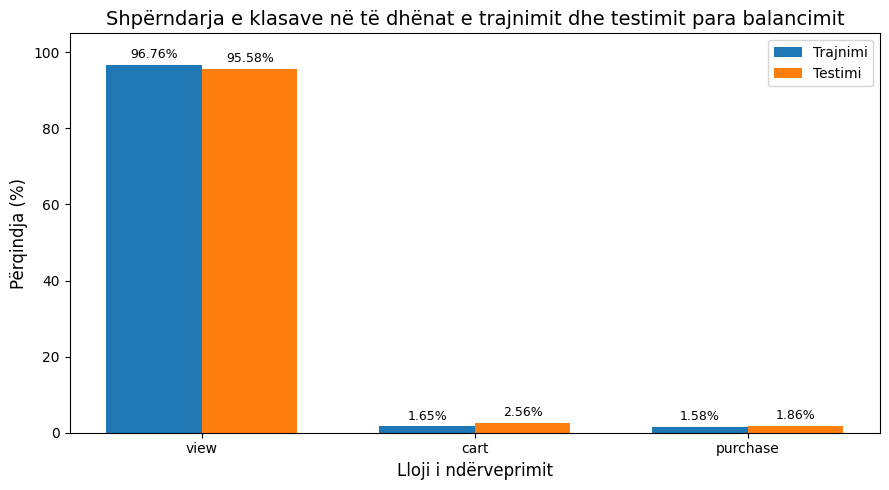

In [26]:
# ============================================================
# SHPËRNDARJA E KLASAVE NË TRAJNIM DHE TESTIM
# PARA BALANCIMIT
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

events = ["view", "cart", "purchase"]

train_percentages = train_distribution["Përqindja"].values
test_percentages = test_distribution["Përqindja"].values

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(9, 5))

bars_train = plt.bar(
    x - width / 2,
    train_percentages,
    width,
    label="Trajnimi"
)

bars_test = plt.bar(
    x + width / 2,
    test_percentages,
    width,
    label="Testimi"
)

plt.title(
    "Shpërndarja e klasave në të dhënat e trajnimit dhe testimit para balancimit",
    fontsize=14
)

plt.xlabel("Lloji i ndërveprimit", fontsize=12)
plt.ylabel("Përqindja (%)", fontsize=12)

plt.xticks(x, events)
plt.ylim(0, 105)

plt.legend()

# Shtimi i etiketave të përqindjeve
for bars in [bars_train, bars_test]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "Figura_2_Shperndarja_Klasave_Trajnim_Testim_Para_Balancimit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# ============================================================
# PËRGATITJA E HYRJEVE PËR MODELET
# ============================================================

print("===== PËRGATITJA E HYRJEVE PËR MODELET =====")

# ------------------------------------------------------------
# HYRJET PËR LSTM
# ------------------------------------------------------------

X_train_lstm = X_train.copy()
X_test_lstm = X_test.copy()

y_train_lstm = y_train.copy()
y_test_lstm = y_test.copy()

print("\n===== HYRJET PËR LSTM =====")

print("Forma e X_train_lstm:", X_train_lstm.shape)
print("Forma e X_test_lstm :", X_test_lstm.shape)

print("Forma e y_train_lstm:", y_train_lstm.shape)
print("Forma e y_test_lstm :", y_test_lstm.shape)

# ------------------------------------------------------------
# HYRJET PËR MODELET TRADICIONALE
# ------------------------------------------------------------

X_train_traditional = X_train.copy()
X_test_traditional = X_test.copy()

y_train_traditional = y_train.copy()
y_test_traditional = y_test.copy()

print("\n===== HYRJET PËR MODELET TRADICIONALE =====")

print(
    "Forma e X_train_traditional:",
    X_train_traditional.shape
)

print(
    "Forma e X_test_traditional :",
    X_test_traditional.shape
)

print(
    "Forma e y_train_traditional:",
    y_train_traditional.shape
)

print(
    "Forma e y_test_traditional :",
    y_test_traditional.shape
)

# ------------------------------------------------------------
# KONTROLLI I PËRPUTHSHMËRISË
# ------------------------------------------------------------

print("\n===== KONTROLLI I PËRPUTHSHMËRISË SË HYRJEVE =====")

print(
    "X_train i LSTM dhe modeleve tradicionale janë identike:",
    np.array_equal(
        X_train_lstm,
        X_train_traditional
    )
)

print(
    "X_test i LSTM dhe modeleve tradicionale janë identike:",
    np.array_equal(
        X_test_lstm,
        X_test_traditional
    )
)

print(
    "y_train i LSTM dhe modeleve tradicionale janë identike:",
    np.array_equal(
        y_train_lstm,
        y_train_traditional
    )
)

print(
    "y_test i LSTM dhe modeleve tradicionale janë identike:",
    np.array_equal(
        y_test_lstm,
        y_test_traditional
    )
)

print("\n===== PËRGATITJA E HYRJEVE PËR MODELET PËRFUNDOI =====")

===== PËRGATITJA E HYRJEVE PËR MODELET =====

===== HYRJET PËR LSTM =====
Forma e X_train_lstm: (1888253, 5)
Forma e X_test_lstm : (472065, 5)
Forma e y_train_lstm: (1888253,)
Forma e y_test_lstm : (472065,)

===== HYRJET PËR MODELET TRADICIONALE =====
Forma e X_train_traditional: (1888253, 5)
Forma e X_test_traditional : (472065, 5)
Forma e y_train_traditional: (1888253,)
Forma e y_test_traditional : (472065,)

===== KONTROLLI I PËRPUTHSHMËRISË SË HYRJEVE =====
X_train i LSTM dhe modeleve tradicionale janë identike: True
X_test i LSTM dhe modeleve tradicionale janë identike: True
y_train i LSTM dhe modeleve tradicionale janë identike: True
y_test i LSTM dhe modeleve tradicionale janë identike: True

===== PËRGATITJA E HYRJEVE PËR MODELET PËRFUNDOI =====


In [29]:
# ============================================================
# NDËRTIMI I MODELIT LSTM - PARA BALANCIMIT
# ============================================================

print("===== NDËRTIMI I MODELIT LSTM - PARA BALANCIMIT =====")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

# Konfigurimi i modelit
VOCAB_SIZE = 3
SEQUENCE_LENGTH = 5
EMBEDDING_DIM = 8
LSTM_UNITS = 32
DROPOUT_RATE = 0.2
DENSE_UNITS = 16
NUM_CLASSES = 3

# Ndërtimi i modelit
lstm_before = Sequential([
    Input(shape=(SEQUENCE_LENGTH,), dtype="int32"),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(LSTM_UNITS),

    Dropout(DROPOUT_RATE),

    Dense(DENSE_UNITS, activation="relu"),

    Dense(NUM_CLASSES, activation="softmax")
])

# Përpilimi i modelit
lstm_before.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Paraqitja e përmbledhjes së modelit
print("\n===== PËRMBLEDHJA E MODELIT LSTM =====")
lstm_before.summary()

===== NDËRTIMI I MODELIT LSTM - PARA BALANCIMIT =====

===== PËRMBLEDHJA E MODELIT LSTM =====


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 5, 8)           │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,851 (22.86 KB)

 Trainable params: 5,851 (22.86 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# ============================================================
# KONTROLLI I PAJISJEVE
# ============================================================

import tensorflow as tf

print("Versioni i TensorFlow:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU e disponueshme:", gpus)
else:
    print("GPU nuk është e disponueshme - trajnimi do të përdorë CPU.")

Versioni i TensorFlow: 2.20.0
GPU nuk është e disponueshme - trajnimi do të përdorë CPU.


In [31]:
# ============================================================
# TRAJNIMI I LSTM - PARA BALANCIMIT
# ============================================================

print("===== TRAJNIMI I LSTM - PARA BALANCIMIT =====")

EPOCHS = 5
BATCH_SIZE = 256
VALIDATION_SPLIT = 0.10

history_lstm_before = lstm_before.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    shuffle=True,
    verbose=1
)

print("\n===== TRAJNIMI I LSTM PËRFUNDOI =====")

===== TRAJNIMI I LSTM - PARA BALANCIMIT =====
Epoch 1/5
6639/6639 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.9705 - loss: 0.1213 - val_accuracy: 0.9648 - val_loss: 0.1356
Epoch 2/5
6639/6639 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - accuracy: 0.9712 - loss: 0.1144 - val_accuracy: 0.9645 - val_loss: 0.1357
Epoch 3/5
6639/6639 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.9713 - loss: 0.1140 - val_accuracy: 0.9648 - val_loss: 0.1341
Epoch 4/5
6639/6639 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9713 - loss: 0.1137 - val_accuracy: 0.9648 - val_loss: 0.1354
Epoch 5/5
6639/6639 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - accuracy: 0.9713 - loss: 0.1135 - val_accuracy: 0.9648 - val_loss: 0.1351

===== TRAJNIMI I LSTM PËRFUNDOI =====


In [32]:
# ============================================================
# PARASHIKIMET E LSTM - PARA BALANCIMIT
# ============================================================

print("===== PARASHIKIMET E LSTM - PARA BALANCIMIT =====")

y_pred_lstm_before_prob = lstm_before.predict(
    X_test_lstm,
    batch_size=256,
    verbose=1
)

y_pred_lstm_before = np.argmax(
    y_pred_lstm_before_prob,
    axis=1
)

print("\n===== PARASHIKIMET PËRFUNDUAN =====")

print("Forma e parashikimeve:", y_pred_lstm_before.shape)
print("Forma e pritur       :", y_test_lstm.shape)

===== PARASHIKIMET E LSTM - PARA BALANCIMIT =====
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

===== PARASHIKIMET PËRFUNDUAN =====
Forma e parashikimeve: (472065,)
Forma e pritur       : (472065,)


In [34]:
# ============================================================
# SHPËRNDARJA E KLASAVE TË PARASHIKUARA NGA LSTM - PARA BALANCIMIT
# ============================================================

print("===== SHPËRNDARJA E KLASAVE TË PARASHIKUARA NGA LSTM =====")

predicted_counts = pd.Series(
    y_pred_lstm_before
).value_counts().sort_index()

predicted_distribution = pd.DataFrame({
    "Ndërveprimi": ["view", "cart", "purchase"],
    "Kodi": [0, 1, 2],
    "Numri i parashikimeve": [
        predicted_counts.get(0, 0),
        predicted_counts.get(1, 0),
        predicted_counts.get(2, 0)
    ]
})

predicted_distribution["Përqindja"] = (
    predicted_distribution["Numri i parashikimeve"]
    / len(y_pred_lstm_before)
    * 100
).round(2)

display(predicted_distribution)

===== SHPËRNDARJA E KLASAVE TË PARASHIKUARA NGA LSTM =====


,Ndërveprimi,Kodi,Numri i parashikimeve,Përqindja
0,view,0,467362,99.00
1,cart,1,2899,0.61
2,purchase,2,1804,0.38


In [35]:
# ============================================================
# VLERËSIMI I LSTM - PARA BALANCIMIT
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("===== VLERËSIMI I LSTM - PARA BALANCIMIT =====")

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

accuracy_lstm_before = accuracy_score(
    y_test_lstm,
    y_pred_lstm_before
)

# ------------------------------------------------------------
# Precision
# ------------------------------------------------------------

precision_lstm_before = precision_score(
    y_test_lstm,
    y_pred_lstm_before,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Recall
# ------------------------------------------------------------

recall_lstm_before = recall_score(
    y_test_lstm,
    y_pred_lstm_before,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# F1-score
# ------------------------------------------------------------

f1_lstm_before = f1_score(
    y_test_lstm,
    y_pred_lstm_before,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Rezultatet
# ------------------------------------------------------------

print(f"Accuracy : {accuracy_lstm_before:.4f}")
print(f"Precision: {precision_lstm_before:.4f}")
print(f"Recall   : {recall_lstm_before:.4f}")
print(f"F1-Score: {f1_lstm_before:.4f}")

# ------------------------------------------------------------
# Raporti i klasifikimit
# ------------------------------------------------------------

print("\n===== RAPORTI I KLASIFIKIMIT =====")

print(
    classification_report(
        y_test_lstm,
        y_pred_lstm_before,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# Matrica e konfuzionit
# ------------------------------------------------------------

print("\n===== MATRICA E KONFUZIONIT =====")

cm_lstm_before = confusion_matrix(
    y_test_lstm,
    y_pred_lstm_before
)

print(cm_lstm_before)

===== VLERËSIMI I LSTM - PARA BALANCIMIT =====
Accuracy : 0.9591
Precision: 0.9465
Recall   : 0.9591
F1-Score: 0.9460

===== RAPORTI I KLASIFIKIMIT =====
              precision    recall  f1-score   support

        view       0.96      1.00      0.98    451186
        cart       0.50      0.12      0.19     12105
    purchase       0.71      0.15      0.24      8774

    accuracy                           0.96    472065
   macro avg       0.73      0.42      0.47    472065
weighted avg       0.95      0.96      0.95    472065


===== MATRICA E KONFUZIONIT =====
[[450012    842    332]
 [ 10460   1462    183]
 [  6890    595   1289]]


In [36]:
# ============================================================
# LOGISTIC REGRESSION - PARA BALANCIMIT
# ============================================================

print("===== NDËRTIMI I LOGISTIC REGRESSION - PARA BALANCIMIT =====")

from sklearn.linear_model import LogisticRegression

logistic_before = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_before.fit(
    X_train_traditional,
    y_train_traditional
)

print("\n===== TRAJNIMI I LOGISTIC REGRESSION PËRFUNDOI =====")

===== NDËRTIMI I LOGISTIC REGRESSION - PARA BALANCIMIT =====

===== TRAJNIMI I LOGISTIC REGRESSION PËRFUNDOI =====


In [37]:
# ============================================================
# PARASHIKIMET E LOGISTIC REGRESSION - PARA BALANCIMIT
# ============================================================

print("===== PARASHIKIMET E LOGISTIC REGRESSION - PARA BALANCIMIT =====")

y_pred_logistic_before = logistic_before.predict(
    X_test_traditional
)

print("\n===== PARASHIKIMET PËRFUNDUAN =====")
print("Forma e parashikimeve:", y_pred_logistic_before.shape)
print("Forma e pritur       :", y_test_traditional.shape)

===== PARASHIKIMET E LOGISTIC REGRESSION - PARA BALANCIMIT =====

===== PARASHIKIMET PËRFUNDUAN =====
Forma e parashikimeve: (472065,)
Forma e pritur       : (472065,)


In [38]:
# ============================================================
# VLERËSIMI I LOGISTIC REGRESSION - PARA BALANCIMIT
# ============================================================

print("===== VLERËSIMI I LOGISTIC REGRESSION - PARA BALANCIMIT =====")

accuracy_logistic_before = accuracy_score(
    y_test_traditional,
    y_pred_logistic_before
)

precision_logistic_before = precision_score(
    y_test_traditional,
    y_pred_logistic_before,
    average="weighted",
    zero_division=0
)

recall_logistic_before = recall_score(
    y_test_traditional,
    y_pred_logistic_before,
    average="weighted",
    zero_division=0
)

f1_logistic_before = f1_score(
    y_test_traditional,
    y_pred_logistic_before,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_logistic_before:.4f}")
print(f"Precision: {precision_logistic_before:.4f}")
print(f"Recall   : {recall_logistic_before:.4f}")
print(f"F1-Score: {f1_logistic_before:.4f}")

print("\n===== RAPORTI I KLASIFIKIMIT =====")

print(
    classification_report(
        y_test_traditional,
        y_pred_logistic_before,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

print("\n===== MATRICA E KONFUZIONIT =====")

cm_logistic_before = confusion_matrix(
    y_test_traditional,
    y_pred_logistic_before
)

print(cm_logistic_before)

===== VLERËSIMI I LOGISTIC REGRESSION - PARA BALANCIMIT =====
Accuracy : 0.9541
Precision: 0.9296
Recall   : 0.9541
F1-Score: 0.9361

===== RAPORTI I KLASIFIKIMIT =====
              precision    recall  f1-score   support

        view       0.96      1.00      0.98    451186
        cart       0.52      0.05      0.09     12105
    purchase       0.07      0.01      0.02      8774

    accuracy                           0.95    472065
   macro avg       0.51      0.35      0.36    472065
weighted avg       0.93      0.95      0.94    472065


===== MATRICA E KONFUZIONIT =====
[[449731    430   1025]
 [ 11467    610     28]
 [  8557    139     78]]


In [39]:
# ============================================================
# DECISION TREE - PARA BALANCIMIT
# ============================================================

print("===== NDËRTIMI I DECISION TREE - PARA BALANCIMIT =====")

from sklearn.tree import DecisionTreeClassifier

decision_tree_before = DecisionTreeClassifier(
    random_state=42
)

decision_tree_before.fit(
    X_train_traditional,
    y_train_traditional
)

print("\n===== TRAJNIMI I DECISION TREE PËRFUNDOI =====")

===== NDËRTIMI I DECISION TREE - PARA BALANCIMIT =====

===== TRAJNIMI I DECISION TREE PËRFUNDOI =====


In [40]:
# ============================================================
# PARASHIKIMET E DECISION TREE - PARA BALANCIMIT
# ============================================================

print("===== PARASHIKIMET E DECISION TREE - PARA BALANCIMIT =====")

y_pred_tree_before = decision_tree_before.predict(
    X_test_traditional
)

print("\n===== PARASHIKIMET PËRFUNDUAN =====")
print("Forma e parashikimeve:", y_pred_tree_before.shape)
print("Forma e pritur       :", y_test_traditional.shape)

===== PARASHIKIMET E DECISION TREE - PARA BALANCIMIT =====

===== PARASHIKIMET PËRFUNDUAN =====
Forma e parashikimeve: (472065,)
Forma e pritur       : (472065,)


In [42]:
# ============================================================
# VLERËSIMI I DECISION TREE - PARA BALANCIMIT
# ============================================================

print("===== VLERËSIMI I DECISION TREE - PARA BALANCIMIT =====")

accuracy_tree_before = accuracy_score(
    y_test_traditional,
    y_pred_tree_before
)

precision_tree_before = precision_score(
    y_test_traditional,
    y_pred_tree_before,
    average="weighted",
    zero_division=0
)

recall_tree_before = recall_score(
    y_test_traditional,
    y_pred_tree_before,
    average="weighted",
    zero_division=0
)

f1_tree_before = f1_score(
    y_test_traditional,
    y_pred_tree_before,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_tree_before:.4f}")
print(f"Precision: {precision_tree_before:.4f}")
print(f"Recall   : {recall_tree_before:.4f}")
print(f"F1-Score: {f1_tree_before:.4f}")

print("\n===== RAPORTI I KLASIFIKIMIT =====")

print(
    classification_report(
        y_test_traditional,
        y_pred_tree_before,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

print("\n===== MATRICA E KONFUZIONIT =====")

cm_tree_before = confusion_matrix(
    y_test_traditional,
    y_pred_tree_before
)

print(cm_tree_before)

===== VLERËSIMI I DECISION TREE - PARA BALANCIMIT =====
Accuracy : 0.9590
Precision: 0.9458
Recall   : 0.9590
F1-Score: 0.9459

===== RAPORTI I KLASIFIKIMIT =====
              precision    recall  f1-score   support

        view       0.96      1.00      0.98    451186
        cart       0.53      0.11      0.18     12105
    purchase       0.64      0.16      0.26      8774

    accuracy                           0.96    472065
   macro avg       0.71      0.42      0.47    472065
weighted avg       0.95      0.96      0.95    472065


===== MATRICA E KONFUZIONIT =====
[[449997    698    491]
 [ 10493   1316    296]
 [  6885    471   1418]]


===== SHPËRNDARJA E KLASAVE NË TRAJNIM DHE TESTIM - PARA BALANCIMIT =====


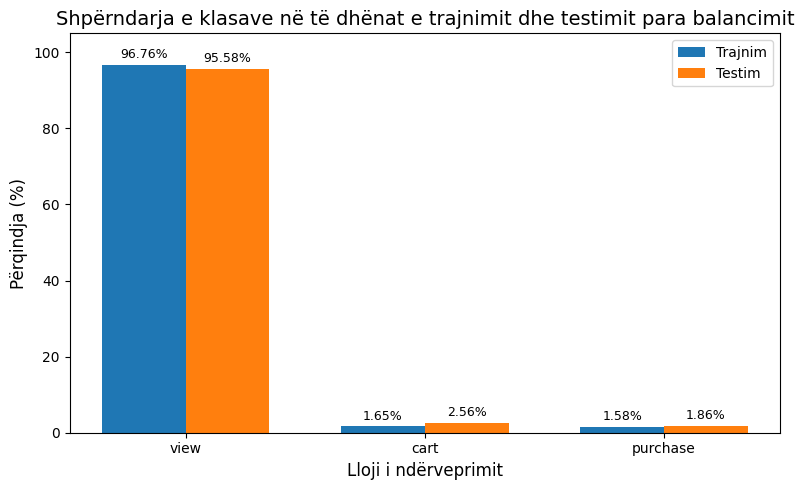

In [43]:
# ============================================================
# SHPËRNDARJA E KLASAVE NË TRAJNIM DHE TESTIM - PARA BALANCIMIT
# ============================================================

print("===== SHPËRNDARJA E KLASAVE NË TRAJNIM DHE TESTIM - PARA BALANCIMIT =====")

events = ["view", "cart", "purchase"]

train_percentages = train_distribution["Përqindja"].values
test_percentages = test_distribution["Përqindja"].values

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(8, 5))

bars_train = plt.bar(
    x - width / 2,
    train_percentages,
    width,
    label="Trajnim"
)

bars_test = plt.bar(
    x + width / 2,
    test_percentages,
    width,
    label="Testim"
)

plt.title(
    "Shpërndarja e klasave në të dhënat e trajnimit dhe testimit para balancimit",
    fontsize=14
)

plt.xlabel("Lloji i ndërveprimit", fontsize=12)
plt.ylabel("Përqindja (%)", fontsize=12)

plt.xticks(x, events)
plt.ylim(0, 105)

plt.legend()

# Shtimi i vlerave të përqindjes
for bars in [bars_train, bars_test]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "Figure_2_Train_Test_Class_Distribution_Before_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

===== KRAHASIMI I MODELEVE - PARA BALANCIMIT =====


,Model,Accuracy,Macro F1-Score
0,Logistic Regression,0.954146,0.361422
1,Decision Tree,0.959044,0.472832
2,LSTM,0.959112,0.472809


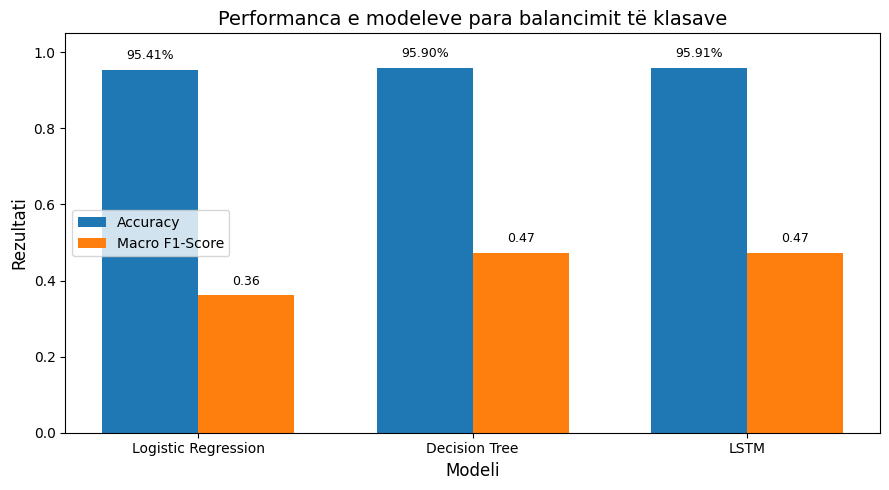

In [45]:
# ============================================================
# KRAHASIMI I MODELEVE - PARA BALANCIMIT
# ============================================================

print("===== KRAHASIMI I MODELEVE - PARA BALANCIMIT =====")

models = [
    "Logistic Regression",
    "Decision Tree",
    "LSTM"
]

accuracy_before = [
    accuracy_logistic_before,
    accuracy_tree_before,
    accuracy_lstm_before
]

macro_f1_before = [
    f1_score(
        y_test_traditional,
        y_pred_logistic_before,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_traditional,
        y_pred_tree_before,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_lstm,
        y_pred_lstm_before,
        average="macro",
        zero_division=0
    )
]

comparison_before = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy_before,
    "Macro F1-Score": macro_f1_before
})

display(comparison_before)

# ============================================================
# VIZUALIZIMI
# ============================================================

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

bars_accuracy = plt.bar(
    x - width / 2,
    accuracy_before,
    width,
    label="Accuracy"
)

bars_macro_f1 = plt.bar(
    x + width / 2,
    macro_f1_before,
    width,
    label="Macro F1-Score"
)

plt.title(
    "Performanca e modeleve para balancimit të klasave",
    fontsize=14
)

plt.xlabel("Modeli", fontsize=12)
plt.ylabel("Rezultati", fontsize=12)

plt.xticks(x, models)
plt.ylim(0, 1.05)

plt.legend()

# Etiketat e Accuracy
for bar, value in zip(bars_accuracy, accuracy_before):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2%}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Etiketat e Macro F1
for bar, value in zip(bars_macro_f1, macro_f1_before):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "Figure_3_Model_Performance_Before_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

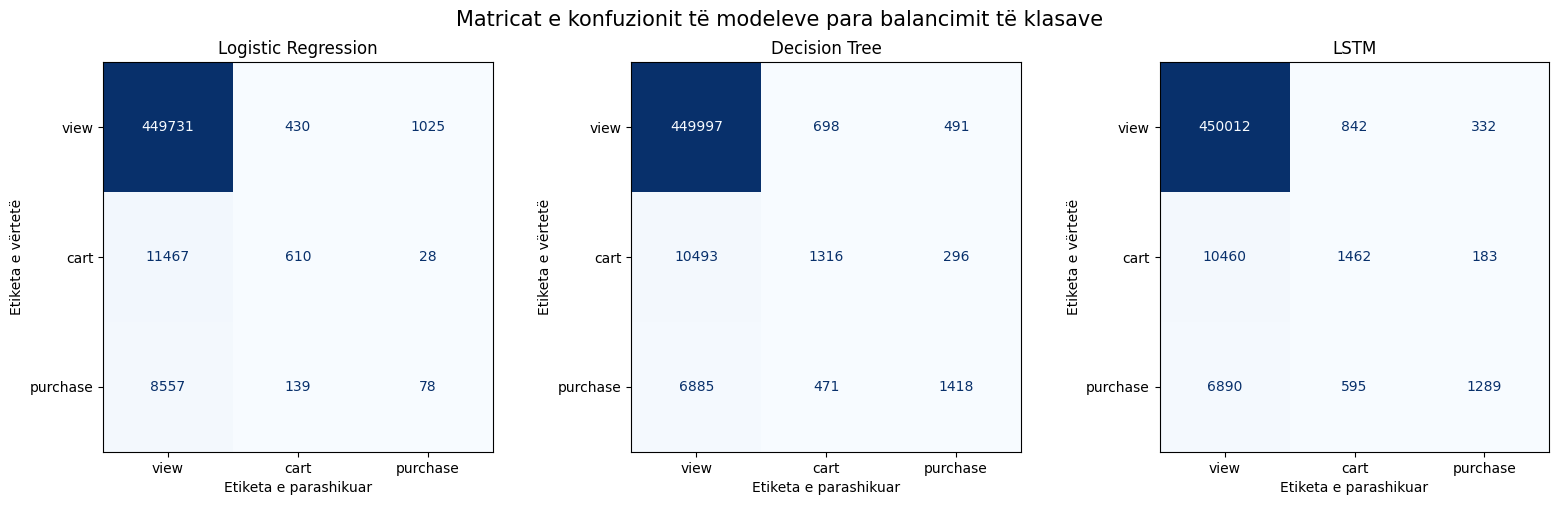

In [46]:
# ============================================================
# MATRICA E KONFUZIONIT - PARA BALANCIMIT
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_cm = [
    ("Logistic Regression", cm_logistic_before),
    ("Decision Tree", cm_tree_before),
    ("LSTM", cm_lstm_before)
]

for ax, (model_name, cm) in zip(axes, models_cm):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["view", "cart", "purchase"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(model_name)
    ax.set_xlabel("Etiketa e parashikuar")
    ax.set_ylabel("Etiketa e vërtetë")

plt.suptitle(
    "Matricat e konfuzionit të modeleve para balancimit të klasave",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "Figure_4_Confusion_Matrices_Before_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# ============================================================
# CLASSIFICATION REPORT - PARA BALANCIMIT
# ============================================================

reports_before = []

model_predictions = {
    "Logistic Regression": (
        y_test_traditional,
        y_pred_logistic_before
    ),
    "Decision Tree": (
        y_test_traditional,
        y_pred_tree_before
    ),
    "LSTM": (
        y_test_lstm,
        y_pred_lstm_before
    )
}

for model_name, (y_true, y_pred) in model_predictions.items():

    report = classification_report(
        y_true,
        y_pred,
        target_names=["view", "cart", "purchase"],
        output_dict=True,
        zero_division=0
    )

    for class_name in ["view", "cart", "purchase"]:

        reports_before.append({
            "Modeli": model_name,
            "Klasa": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1-Score": report[class_name]["f1-score"],
            "Support": int(report[class_name]["support"])
        })

classification_report_before_df = pd.DataFrame(
    reports_before
)

print("===== CLASSIFICATION REPORT - PARA BALANCIMIT =====")

display(
    classification_report_before_df.round({
        "Precision": 2,
        "Recall": 2,
        "F1-Score": 2
    })
)

===== CLASSIFICATION REPORT - PARA BALANCIMIT =====


,Modeli,Klasa,Precision,Recall,F1-Score,Support
0,Logistic Regression,view,0.96,1.00,0.98,451186
1,Logistic Regression,cart,0.52,0.05,0.09,12105
2,Logistic Regression,purchase,0.07,0.01,0.02,8774
3,Decision Tree,view,0.96,1.00,0.98,451186
4,Decision Tree,cart,0.53,0.11,0.18,12105
5,Decision Tree,purchase,0.64,0.16,0.26,8774
6,LSTM,view,0.96,1.00,0.98,451186
7,LSTM,cart,0.50,0.12,0.19,12105
8,LSTM,purchase,0.71,0.15,0.24,8774


In [48]:
# ============================================================
# BALANCIMI I KLASAVE - RANDOM UNDERSAMPLING
# ============================================================

print("===== BALANCIMI I KLASAVE - RANDOM UNDERSAMPLING =====")

from imblearn.under_sampling import RandomUnderSampler

# ------------------------------------------------------------
# SHPËRNDARJA ORIGJINALE E TË DHËNAVE TË TRAJNIMIT
# ------------------------------------------------------------

print("\n===== PARA RANDOM UNDERSAMPLING =====")

before_counts = pd.Series(y_train).value_counts().sort_index()

before_distribution = pd.DataFrame({
    "Kodi": [0, 1, 2],
    "Ndërveprimi": ["view", "cart", "purchase"],
    "Numri": [
        before_counts.get(0, 0),
        before_counts.get(1, 0),
        before_counts.get(2, 0)
    ]
})

before_distribution["Përqindja"] = (
    before_distribution["Numri"]
    / len(y_train)
    * 100
).round(2)

display(before_distribution)

# ------------------------------------------------------------
# RANDOM UNDERSAMPLING
# ------------------------------------------------------------

print("\n===== APLIKIMI I RANDOM UNDERSAMPLING =====")

undersampler = RandomUnderSampler(
    sampling_strategy="not minority",
    random_state=42
)

X_train_balanced, y_train_balanced = undersampler.fit_resample(
    X_train_traditional,
    y_train_traditional
)

# ------------------------------------------------------------
# SHPËRNDARJA E TË DHËNAVE TË TRAJNIMIT PAS BALANCIMIT
# ------------------------------------------------------------

print("\n===== PAS RANDOM UNDERSAMPLING =====")

after_counts = pd.Series(y_train_balanced).value_counts().sort_index()

after_distribution = pd.DataFrame({
    "Kodi": [0, 1, 2],
    "Ndërveprimi": ["view", "cart", "purchase"],
    "Numri": [
        after_counts.get(0, 0),
        after_counts.get(1, 0),
        after_counts.get(2, 0)
    ]
})

after_distribution["Përqindja"] = (
    after_distribution["Numri"]
    / len(y_train_balanced)
    * 100
).round(2)

display(after_distribution)

# ------------------------------------------------------------
# DIMENSIONET
# ------------------------------------------------------------

print("\n===== DIMENSIONET E TË DHËNAVE TË TRAJNIMIT PAS BALANCIMIT =====")

print("Original X_train shape :", X_train_traditional.shape)
print("Balanced X_train shape :", X_train_balanced.shape)

print("Original y_train shape :", y_train_traditional.shape)
print("Balanced y_train shape :", y_train_balanced.shape)

# ------------------------------------------------------------
# VALIDIMI
# ------------------------------------------------------------

print("\n===== VALIDIMI I BALANCIMIT =====")

balanced_counts = pd.Series(y_train_balanced).value_counts()

print(
    "Klasat janë të balancuara:",
    balanced_counts.nunique() == 1
)

print(
    "Të dhënat e testimit janë të pandryshuara:",
    len(y_test_traditional) == 472065
)

print(
    "Shpërndarja e të dhënave të testimit është e pandryshuar:",
    np.array_equal(
        y_test_traditional,
        y_test
    )
)

print("\n===== RANDOM UNDERSAMPLING U PËRFUNDUE =====")

===== BALANCIMI I KLASAVE - RANDOM UNDERSAMPLING =====

===== PARA RANDOM UNDERSAMPLING =====


,Kodi,Ndërveprimi,Numri,Përqindja
0,0,view,1827167,96.76
1,1,cart,31169,1.65
2,2,purchase,29917,1.58



===== APLIKIMI I RANDOM UNDERSAMPLING =====

===== PAS RANDOM UNDERSAMPLING =====


,Kodi,Ndërveprimi,Numri,Përqindja
0,0,view,29917,33.33
1,1,cart,29917,33.33
2,2,purchase,29917,33.33



===== DIMENSIONET E TË DHËNAVE TË TRAJNIMIT PAS BALANCIMIT =====
Original X_train shape : (1888253, 5)
Balanced X_train shape : (89751, 5)
Original y_train shape : (1888253,)
Balanced y_train shape : (89751,)

===== VALIDIMI I BALANCIMIT =====
Klasat janë të balancuara: True
Të dhënat e testimit janë të pandryshuara: True
Shpërndarja e të dhënave të testimit është e pandryshuar: True

===== RANDOM UNDERSAMPLING U PËRFUNDUE =====


===== SHPËRNDARJA E KLASAVE PARA DHE PAS BALANCIMIT =====


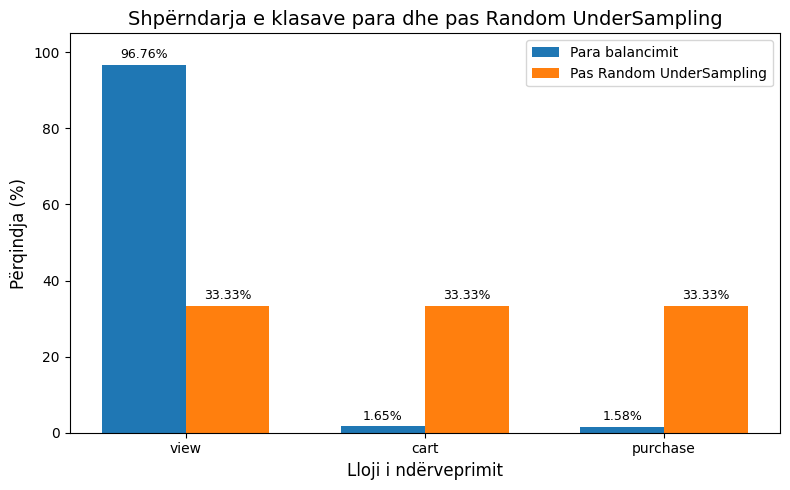

In [49]:
# ============================================================
# SHPËRNDARJA E KLASAVE PARA DHE PAS RANDOM UNDERSAMPLING
# ============================================================

print("===== SHPËRNDARJA E KLASAVE PARA DHE PAS BALANCIMIT =====")

events = ["view", "cart", "purchase"]

before_percentages = before_distribution["Përqindja"].values
after_percentages = after_distribution["Përqindja"].values

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(8, 5))

bars_before = plt.bar(
    x - width / 2,
    before_percentages,
    width,
    label="Para balancimit"
)

bars_after = plt.bar(
    x + width / 2,
    after_percentages,
    width,
    label="Pas Random UnderSampling"
)

plt.title(
    "Shpërndarja e klasave para dhe pas Random UnderSampling",
    fontsize=14
)

plt.xlabel("Lloji i ndërveprimit", fontsize=12)
plt.ylabel("Përqindja (%)", fontsize=12)

plt.xticks(x, events)
plt.ylim(0, 105)

plt.legend()

for bars in [bars_before, bars_after]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "Figure_5_Class_Distribution_Before_After_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
# ============================================================
# PËRGATITJA E TË DHËNAVE TË TRAJNIMIT TË BALANCUARA PËR LSTM
# ============================================================

print("===== PËRGATITJA E TË DHËNAVE TË TRAJNIMIT TË BALANCUARA PËR LSTM =====")

# ------------------------------------------------------------
# TË DHËNAT E TRAJNIMIT TË BALANCUARA
# ------------------------------------------------------------

X_train_balanced_lstm = X_train_balanced.copy()
y_train_balanced_lstm = y_train_balanced.copy()

# ------------------------------------------------------------
# TË DHËNAT E TESTIMIT MBETEN TË PANDRYSHUARA
# ------------------------------------------------------------

X_test_lstm_after = X_test_lstm.copy()
y_test_lstm_after = y_test_lstm.copy()

# ------------------------------------------------------------
# DIMENSIONET
# ------------------------------------------------------------

print("\n===== HYRJET E BALANCUARA PËR LSTM =====")

print(
    "Dimensionet e X_train_balanced_lstm:",
    X_train_balanced_lstm.shape
)

print(
    "Dimensionet e y_train_balanced_lstm:",
    y_train_balanced_lstm.shape
)

print(
    "Dimensionet e X_test_lstm_after:",
    X_test_lstm_after.shape
)

print(
    "Dimensionet e y_test_lstm_after:",
    y_test_lstm_after.shape
)

# ------------------------------------------------------------
# KONTROLLI I KONSISTENCËS
# ------------------------------------------------------------

print("\n===== VALIDIMI I HYRJEVE TË BALANCUARA PËR LSTM =====")

print(
    "Përputhja ndërmjet X_train dhe y_train:",
    X_train_balanced_lstm.shape[0]
    == y_train_balanced_lstm.shape[0]
)

print(
    "Gjatësia e sekuencës është e saktë:",
    X_train_balanced_lstm.shape[1]
    == SEQUENCE_LENGTH
)

print(
    "Të dhënat e testimit janë të pandryshuara:",
    X_test_lstm_after.shape
    == X_test_lstm.shape
)

print(
    "Targetet e testimit janë të pandryshuara:",
    np.array_equal(
        y_test_lstm_after,
        y_test_lstm
    )
)

print("\n===== PËRGATITJA E HYRJEVE TË BALANCUARA PËR LSTM U PËRFUNDUE =====")

===== PËRGATITJA E TË DHËNAVE TË TRAJNIMIT TË BALANCUARA PËR LSTM =====

===== HYRJET E BALANCUARA PËR LSTM =====
Dimensionet e X_train_balanced_lstm: (89751, 5)
Dimensionet e y_train_balanced_lstm: (89751,)
Dimensionet e X_test_lstm_after: (472065, 5)
Dimensionet e y_test_lstm_after: (472065,)

===== VALIDIMI I HYRJEVE TË BALANCUARA PËR LSTM =====
Përputhja ndërmjet X_train dhe y_train: True
Gjatësia e sekuencës është e saktë: True
Të dhënat e testimit janë të pandryshuara: True
Targetet e testimit janë të pandryshuara: True

===== PËRGATITJA E HYRJEVE TË BALANCUARA PËR LSTM U PËRFUNDUE =====


In [52]:
# ============================================================
# NDËRTIMI I MODELIT LSTM - PAS BALANCIMIT
# ============================================================

print("===== NDËRTIMI I MODELIT LSTM - PAS BALANCIMIT =====")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

# ------------------------------------------------------------
# KONFIGURIMI I MODELIT
# E njëjta arkitekturë si LSTM para balancimit
# ------------------------------------------------------------

VOCAB_SIZE = 3
SEQUENCE_LENGTH = 5
EMBEDDING_DIM = 8
LSTM_UNITS = 32
DROPOUT_RATE = 0.2
DENSE_UNITS = 16
NUM_CLASSES = 3

# ------------------------------------------------------------
# NDËRTIMI I MODELIT TË RI LSTM
# ------------------------------------------------------------

lstm_after = Sequential([
    Input(
        shape=(SEQUENCE_LENGTH,),
        dtype="int32"
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(LSTM_UNITS),

    Dropout(DROPOUT_RATE),

    Dense(
        DENSE_UNITS,
        activation="relu"
    ),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

# ------------------------------------------------------------
# KOMPILIMI
# ------------------------------------------------------------

lstm_after.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# PËRMBLEDHJA E MODELIT
# ------------------------------------------------------------

print("\n===== PËRMBLEDHJA E MODELIT LSTM - PAS BALANCIMIT =====")

lstm_after.summary()

print("\n===== MODELI LSTM PAS BALANCIMIT ËSHTË GATI =====")

===== NDËRTIMI I MODELIT LSTM - PAS BALANCIMIT =====

===== PËRMBLEDHJA E MODELIT LSTM - PAS BALANCIMIT =====


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 5, 8)           │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,851 (22.86 KB)

 Trainable params: 5,851 (22.86 KB)

 Non-trainable params: 0 (0.00 B)


===== MODELI LSTM PAS BALANCIMIT ËSHTË GATI =====


In [53]:
# ============================================================
# TRAJNIMI I LSTM - PAS BALANCIMIT
# ============================================================

print("===== TRAJNIMI I LSTM - PAS BALANCIMIT =====")

EPOCHS = 5
BATCH_SIZE = 256
VALIDATION_SPLIT = 0.10

history_lstm_after = lstm_after.fit(
    X_train_balanced_lstm,
    y_train_balanced_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    shuffle=True,
    verbose=1
)

print("\n===== TRAJNIMI I LSTM PAS BALANCIMIT U PËRFUNDUE =====")

===== TRAJNIMI I LSTM - PAS BALANCIMIT =====
Epoch 1/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5984 - loss: 0.8998 - val_accuracy: 0.5354 - val_loss: 0.9953
Epoch 2/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6446 - loss: 0.8393 - val_accuracy: 0.5360 - val_loss: 0.9794
Epoch 3/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6457 - loss: 0.8316 - val_accuracy: 0.5397 - val_loss: 1.0032
Epoch 4/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6461 - loss: 0.8273 - val_accuracy: 0.4765 - val_loss: 1.0226
Epoch 5/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6467 - loss: 0.8252 - val_accuracy: 0.4764 - val_loss: 1.0244

===== TRAJNIMI I LSTM PAS BALANCIMIT U PËRFUNDUE =====


In [54]:
# ============================================================
# PARASHIKIMET E LSTM - PAS BALANCIMIT
# ============================================================

print("===== PARASHIKIMET E LSTM - PAS BALANCIMIT =====")

y_pred_lstm_after_prob = lstm_after.predict(
    X_test_lstm_after,
    batch_size=256,
    verbose=1
)

# Shndërrimi i probabiliteteve në klasa të parashikuara
y_pred_lstm_after = np.argmax(
    y_pred_lstm_after_prob,
    axis=1
)

print("\n===== PARASHIKIMET U PËRFUNDuan =====")

print(
    "Forma e parashikimeve:",
    y_pred_lstm_after.shape
)

print(
    "Forma e pritshme     :",
    y_test_lstm_after.shape
)

===== PARASHIKIMET E LSTM - PAS BALANCIMIT =====
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

===== PARASHIKIMET U PËRFUNDuan =====
Forma e parashikimeve: (472065,)
Forma e pritshme     : (472065,)


In [55]:
# ============================================================
# VLERËSIMI I LSTM - PAS BALANCIMIT
# ============================================================

print("===== VLERËSIMI I LSTM - PAS BALANCIMIT =====")

# ------------------------------------------------------------
# METRIKAT
# ------------------------------------------------------------

accuracy_lstm_after = accuracy_score(
    y_test_lstm_after,
    y_pred_lstm_after
)

precision_lstm_after = precision_score(
    y_test_lstm_after,
    y_pred_lstm_after,
    average="weighted",
    zero_division=0
)

recall_lstm_after = recall_score(
    y_test_lstm_after,
    y_pred_lstm_after,
    average="weighted",
    zero_division=0
)

f1_lstm_after = f1_score(
    y_test_lstm_after,
    y_pred_lstm_after,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_lstm_after:.4f}")
print(f"Precision: {precision_lstm_after:.4f}")
print(f"Recall   : {recall_lstm_after:.4f}")
print(f"F1-Score: {f1_lstm_after:.4f}")

# ------------------------------------------------------------
# RAPORTI I KLASIFIKIMIT
# ------------------------------------------------------------

print("\n===== RAPORTI I KLASIFIKIMIT =====")

print(
    classification_report(
        y_test_lstm_after,
        y_pred_lstm_after,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# MATRICA E KONFUZIONIT
# ------------------------------------------------------------

print("===== MATRICA E KONFUZIONIT =====")

cm_lstm_after = confusion_matrix(
    y_test_lstm_after,
    y_pred_lstm_after
)

print(cm_lstm_after)

print("\n===== VLERËSIMI I LSTM PAS BALANCIMIT U PËRFUNDUE =====")

===== VLERËSIMI I LSTM - PAS BALANCIMIT =====
Accuracy : 0.9093
Precision: 0.9503
Recall   : 0.9093
F1-Score: 0.9267

===== RAPORTI I KLASIFIKIMIT =====
              precision    recall  f1-score   support

        view       0.98      0.93      0.96    451186
        cart       0.21      0.53      0.30     12105
    purchase       0.26      0.46      0.33      8774

    accuracy                           0.91    472065
   macro avg       0.49      0.64      0.53    472065
weighted avg       0.95      0.91      0.93    472065

===== MATRICA E KONFUZIONIT =====
[[418720  22327  10139]
 [  4297   6464   1344]
 [  2694   2006   4074]]

===== VLERËSIMI I LSTM PAS BALANCIMIT U PËRFUNDUE =====


In [56]:
# ============================================================
# LOGISTIC REGRESSION - PAS BALANCIMIT
# ============================================================

print("===== NDËRTIMI I LOGISTIC REGRESSION - PAS BALANCIMIT =====")

from sklearn.linear_model import LogisticRegression

logistic_after = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_after.fit(
    X_train_balanced,
    y_train_balanced
)

print("===== TRAJNIMI I LOGISTIC REGRESSION PAS BALANCIMIT U PËRFUNDUE =====")

===== NDËRTIMI I LOGISTIC REGRESSION - PAS BALANCIMIT =====
===== TRAJNIMI I LOGISTIC REGRESSION PAS BALANCIMIT U PËRFUNDUE =====


In [57]:
# ============================================================
# PARASHIKIMET E LOGISTIC REGRESSION - PAS BALANCIMIT
# ============================================================

print("===== PARASHIKIMET E LOGISTIC REGRESSION - PAS BALANCIMIT =====")

y_pred_logistic_after = logistic_after.predict(
    X_test_traditional
)

print("\n===== PARASHIKIMET U PËRFUNDUAN =====")
print(
    "Forma e parashikimeve:",
    y_pred_logistic_after.shape
)
print(
    "Forma e pritshme     :",
    y_test_traditional.shape
)

===== PARASHIKIMET E LOGISTIC REGRESSION - PAS BALANCIMIT =====

===== PARASHIKIMET U PËRFUNDUAN =====
Forma e parashikimeve: (472065,)
Forma e pritshme     : (472065,)


In [58]:
# ============================================================
# VLERËSIMI I LOGISTIC REGRESSION - PAS BALANCIMIT
# ============================================================

print("===== VLERËSIMI I LOGISTIC REGRESSION - PAS BALANCIMIT =====")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# METRIKAT
# ------------------------------------------------------------

accuracy_logistic_after = accuracy_score(
    y_test_traditional,
    y_pred_logistic_after
)

precision_logistic_after = precision_score(
    y_test_traditional,
    y_pred_logistic_after,
    average="weighted",
    zero_division=0
)

recall_logistic_after = recall_score(
    y_test_traditional,
    y_pred_logistic_after,
    average="weighted",
    zero_division=0
)

f1_logistic_after = f1_score(
    y_test_traditional,
    y_pred_logistic_after,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_logistic_after:.4f}")
print(f"Precision: {precision_logistic_after:.4f}")
print(f"Recall   : {recall_logistic_after:.4f}")
print(f"F1-Score: {f1_logistic_after:.4f}")

# ------------------------------------------------------------
# RAPORTI I KLASIFIKIMIT
# ------------------------------------------------------------

print("\n===== RAPORTI I KLASIFIKIMIT =====")

print(
    classification_report(
        y_test_traditional,
        y_pred_logistic_after,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# MATRICA E KONFUZIONIT
# ------------------------------------------------------------

print("===== MATRICA E KONFUZIONIT =====")

cm_logistic_after = confusion_matrix(
    y_test_traditional,
    y_pred_logistic_after
)

print(cm_logistic_after)

print("\n===== VLERËSIMI I LOGISTIC REGRESSION U PËRFUNDUE =====")

===== VLERËSIMI I LOGISTIC REGRESSION - PAS BALANCIMIT =====
Accuracy : 0.9043
Precision: 0.9494
Recall   : 0.9043
F1-Score: 0.9235

===== RAPORTI I KLASIFIKIMIT =====
              precision    recall  f1-score   support

        view       0.98      0.92      0.95    451186
        cart       0.22      0.47      0.30     12105
    purchase       0.19      0.51      0.28      8774

    accuracy                           0.90    472065
   macro avg       0.47      0.63      0.51    472065
weighted avg       0.95      0.90      0.92    472065

===== MATRICA E KONFUZIONIT =====
[[416773  18018  16395]
 [  4297   5654   2154]
 [  2690   1608   4476]]

===== VLERËSIMI I LOGISTIC REGRESSION U PËRFUNDUE =====


In [59]:
# ============================================================
# DECISION TREE - PAS BALANCIMIT
# ============================================================

print("===== NDËRTIMI I DECISION TREE - PAS BALANCIMIT =====")

from sklearn.tree import DecisionTreeClassifier

decision_tree_after = DecisionTreeClassifier(
    random_state=42
)

decision_tree_after.fit(
    X_train_balanced,
    y_train_balanced
)

print("===== TRAJNIMI I DECISION TREE PAS BALANCIMIT U PËRFUNDUE =====")

===== NDËRTIMI I DECISION TREE - PAS BALANCIMIT =====
===== TRAJNIMI I DECISION TREE PAS BALANCIMIT U PËRFUNDUE =====


In [60]:
# ============================================================
# PARASHIKIMET E DECISION TREE - PAS BALANCIMIT
# ============================================================

print("===== PARASHIKIMET E DECISION TREE - PAS BALANCIMIT =====")

y_pred_tree_after = decision_tree_after.predict(
    X_test_traditional
)

print("\n===== PARASHIKIMET U PËRFUNDUAN =====")

print(
    "Forma e parashikimeve:",
    y_pred_tree_after.shape
)

print(
    "Forma e pritshme     :",
    y_test_traditional.shape
)

===== PARASHIKIMET E DECISION TREE - PAS BALANCIMIT =====

===== PARASHIKIMET U PËRFUNDUAN =====
Forma e parashikimeve: (472065,)
Forma e pritshme     : (472065,)


In [61]:
# ============================================================
# VLERËSIMI I DECISION TREE - PAS BALANCIMIT
# ============================================================

print("===== VLERËSIMI I DECISION TREE - PAS BALANCIMIT =====")

# ------------------------------------------------------------
# METRIKAT
# ------------------------------------------------------------

accuracy_tree_after = accuracy_score(
    y_test_traditional,
    y_pred_tree_after
)

precision_tree_after = precision_score(
    y_test_traditional,
    y_pred_tree_after,
    average="weighted",
    zero_division=0
)

recall_tree_after = recall_score(
    y_test_traditional,
    y_pred_tree_after,
    average="weighted",
    zero_division=0
)

f1_tree_after = f1_score(
    y_test_traditional,
    y_pred_tree_after,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_tree_after:.4f}")
print(f"Precision: {precision_tree_after:.4f}")
print(f"Recall   : {recall_tree_after:.4f}")
print(f"F1-Score: {f1_tree_after:.4f}")

# ------------------------------------------------------------
# RAPORTI I KLASIFIKIMIT
# ------------------------------------------------------------

print("\n===== RAPORTI I KLASIFIKIMIT =====")

print(
    classification_report(
        y_test_traditional,
        y_pred_tree_after,
        target_names=["view", "cart", "purchase"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# MATRICA E KONFUZIONIT
# ------------------------------------------------------------

print("===== MATRICA E KONFUZIONIT =====")

cm_tree_after = confusion_matrix(
    y_test_traditional,
    y_pred_tree_after
)

print(cm_tree_after)

print("\n===== VLERËSIMI I DECISION TREE U PËRFUNDUE =====")

===== VLERËSIMI I DECISION TREE - PAS BALANCIMIT =====
Accuracy : 0.9176
Precision: 0.9516
Recall   : 0.9176
F1-Score: 0.9319

===== RAPORTI I KLASIFIKIMIT =====
              precision    recall  f1-score   support

        view       0.98      0.94      0.96    451186
        cart       0.24      0.51      0.32     12105
    purchase       0.29      0.56      0.38      8774

    accuracy                           0.92    472065
   macro avg       0.50      0.67      0.55    472065
weighted avg       0.95      0.92      0.93    472065

===== MATRICA E KONFUZIONIT =====
[[422102  18505  10579]
 [  4311   6120   1674]
 [  2699   1145   4930]]

===== VLERËSIMI I DECISION TREE U PËRFUNDUE =====


===== KRAHASIMI I MODELEVE - PAS BALANCIMIT =====


,Model,Accuracy,Macro F1-Score
0,Logistic Regression,0.904331,0.512225
1,Decision Tree,0.917569,0.554008
2,LSTM,0.909320,0.530408


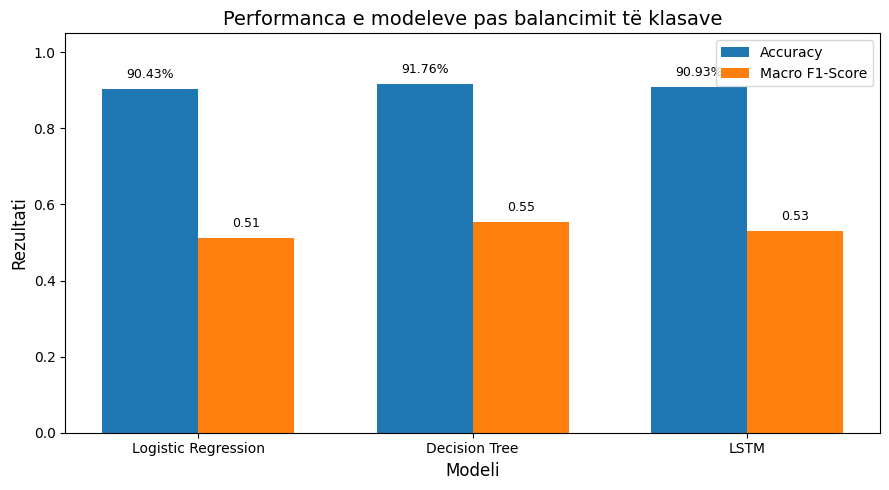

In [62]:
# ============================================================
# KRAHASIMI I MODELEVE - PAS BALANCIMIT
# ============================================================

print("===== KRAHASIMI I MODELEVE - PAS BALANCIMIT =====")

models = [
    "Logistic Regression",
    "Decision Tree",
    "LSTM"
]

accuracy_after = [
    accuracy_logistic_after,
    accuracy_tree_after,
    accuracy_lstm_after
]

macro_f1_after = [
    f1_score(
        y_test_traditional,
        y_pred_logistic_after,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_traditional,
        y_pred_tree_after,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_lstm,
        y_pred_lstm_after,
        average="macro",
        zero_division=0
    )
]

comparison_after = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy_after,
    "Macro F1-Score": macro_f1_after
})

display(comparison_after)

# ============================================================
# VIZUALIZIMI
# ============================================================

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

bars_accuracy = plt.bar(
    x - width / 2,
    accuracy_after,
    width,
    label="Accuracy"
)

bars_macro_f1 = plt.bar(
    x + width / 2,
    macro_f1_after,
    width,
    label="Macro F1-Score"
)

plt.title(
    "Performanca e modeleve pas balancimit të klasave",
    fontsize=14
)

plt.xlabel("Modeli", fontsize=12)
plt.ylabel("Rezultati", fontsize=12)

plt.xticks(x, models)
plt.ylim(0, 1.05)

plt.legend()

# Etiketat e Accuracy
for bar, value in zip(bars_accuracy, accuracy_after):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2%}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Etiketat e Macro F1
for bar, value in zip(bars_macro_f1, macro_f1_after):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "Figure_6_Model_Performance_After_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

===== KRAHASIMI PËRFUNDIMTAR I MODELEVE - PARA DHE PAS BALANCIMIT =====


,Model,Accuracy Before,Accuracy After,Macro F1 Before,Macro F1 After
0,Logistic Regression,0.954146,0.904331,0.361422,0.512225
1,Decision Tree,0.959044,0.917569,0.472832,0.554008
2,LSTM,0.959112,0.909320,0.472809,0.530408


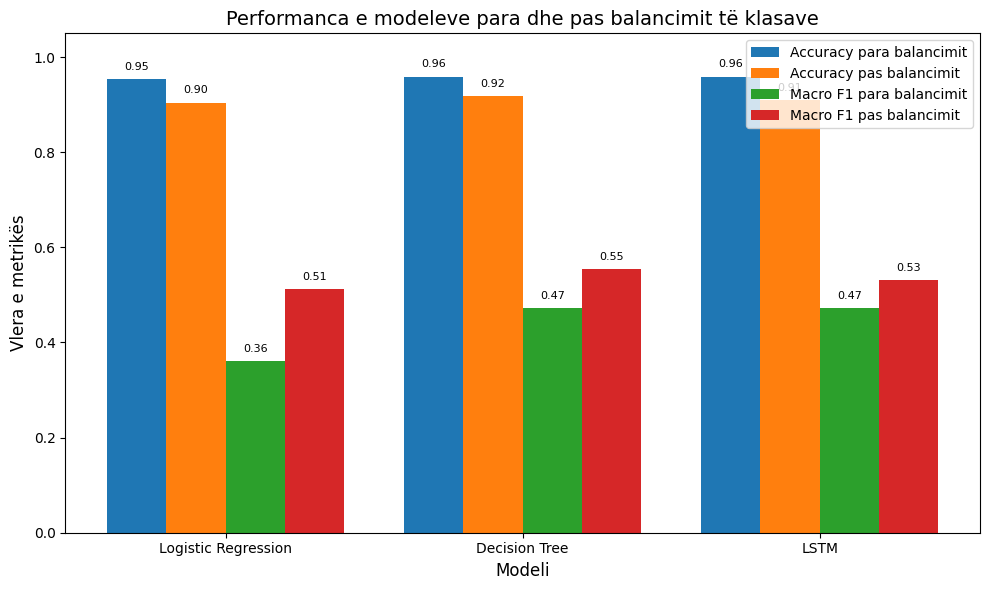

In [63]:
# ============================================================
# KRAHASIMI PËRFUNDIMTAR I MODELEVE - PARA DHE PAS BALANCIMIT
# ============================================================

print("===== KRAHASIMI PËRFUNDIMTAR I MODELEVE - PARA DHE PAS BALANCIMIT =====")

models = [
    "Logistic Regression",
    "Decision Tree",
    "LSTM"
]

# Accuracy
accuracy_before = [
    accuracy_logistic_before,
    accuracy_tree_before,
    accuracy_lstm_before
]

accuracy_after = [
    accuracy_logistic_after,
    accuracy_tree_after,
    accuracy_lstm_after
]

# Macro F1
macro_f1_before = [
    f1_score(
        y_test_traditional,
        y_pred_logistic_before,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_traditional,
        y_pred_tree_before,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_lstm,
        y_pred_lstm_before,
        average="macro",
        zero_division=0
    )
]

macro_f1_after = [
    f1_score(
        y_test_traditional,
        y_pred_logistic_after,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_traditional,
        y_pred_tree_after,
        average="macro",
        zero_division=0
    ),
    f1_score(
        y_test_lstm_after,
        y_pred_lstm_after,
        average="macro",
        zero_division=0
    )
]

# Krijimi i tabelës përmbledhëse
final_comparison = pd.DataFrame({
    "Model": models,
    "Accuracy Before": accuracy_before,
    "Accuracy After": accuracy_after,
    "Macro F1 Before": macro_f1_before,
    "Macro F1 After": macro_f1_after
})

display(final_comparison)

# ------------------------------------------------------------
# VIZUALIZIMI
# ------------------------------------------------------------

x = np.arange(len(models))
width = 0.20

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - 1.5 * width,
    accuracy_before,
    width,
    label="Accuracy para balancimit"
)

bars2 = plt.bar(
    x - 0.5 * width,
    accuracy_after,
    width,
    label="Accuracy pas balancimit"
)

bars3 = plt.bar(
    x + 0.5 * width,
    macro_f1_before,
    width,
    label="Macro F1 para balancimit"
)

bars4 = plt.bar(
    x + 1.5 * width,
    macro_f1_after,
    width,
    label="Macro F1 pas balancimit"
)

plt.title(
    "Performanca e modeleve para dhe pas balancimit të klasave",
    fontsize=14
)

plt.xlabel("Modeli", fontsize=12)
plt.ylabel("Vlera e metrikës", fontsize=12)

plt.xticks(x, models)
plt.ylim(0, 1.05)

plt.legend()

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    "Figure_6_Final_Model_Comparison_Before_After_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

===== KRAHASIMI I RECALL PËR KLASAT MINORITARE =====


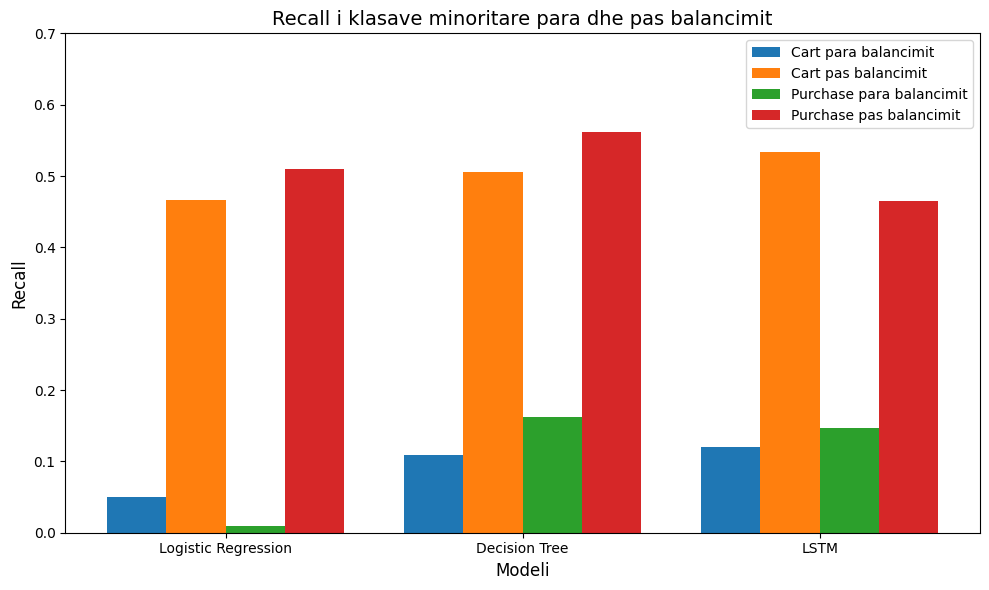

In [64]:
# ============================================================
# RECALL I KLASAVE MINORITARE - PARA DHE PAS BALANCIMIT
# ============================================================

print("===== KRAHASIMI I RECALL PËR KLASAT MINORITARE =====")

cart_recall_before = [
    recall_score(
        y_test_traditional,
        y_pred_logistic_before,
        labels=[1],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_traditional,
        y_pred_tree_before,
        labels=[1],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_lstm,
        y_pred_lstm_before,
        labels=[1],
        average="macro",
        zero_division=0
    )
]

cart_recall_after = [
    recall_score(
        y_test_traditional,
        y_pred_logistic_after,
        labels=[1],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_traditional,
        y_pred_tree_after,
        labels=[1],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_lstm_after,
        y_pred_lstm_after,
        labels=[1],
        average="macro",
        zero_division=0
    )
]

purchase_recall_before = [
    recall_score(
        y_test_traditional,
        y_pred_logistic_before,
        labels=[2],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_traditional,
        y_pred_tree_before,
        labels=[2],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_lstm,
        y_pred_lstm_before,
        labels=[2],
        average="macro",
        zero_division=0
    )
]

purchase_recall_after = [
    recall_score(
        y_test_traditional,
        y_pred_logistic_after,
        labels=[2],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_traditional,
        y_pred_tree_after,
        labels=[2],
        average="macro",
        zero_division=0
    ),
    recall_score(
        y_test_lstm_after,
        y_pred_lstm_after,
        labels=[2],
        average="macro",
        zero_division=0
    )
]

x = np.arange(len(models))
width = 0.20

plt.figure(figsize=(10, 6))

plt.bar(
    x - 1.5 * width,
    cart_recall_before,
    width,
    label="Cart para balancimit"
)

plt.bar(
    x - 0.5 * width,
    cart_recall_after,
    width,
    label="Cart pas balancimit"
)

plt.bar(
    x + 0.5 * width,
    purchase_recall_before,
    width,
    label="Purchase para balancimit"
)

plt.bar(
    x + 1.5 * width,
    purchase_recall_after,
    width,
    label="Purchase pas balancimit"
)

plt.title(
    "Recall i klasave minoritare para dhe pas balancimit",
    fontsize=14
)

plt.xlabel("Modeli", fontsize=12)
plt.ylabel("Recall", fontsize=12)

plt.xticks(x, models)
plt.ylim(0, 0.70)

plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure_7_Minority_Class_Recall_Before_After_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

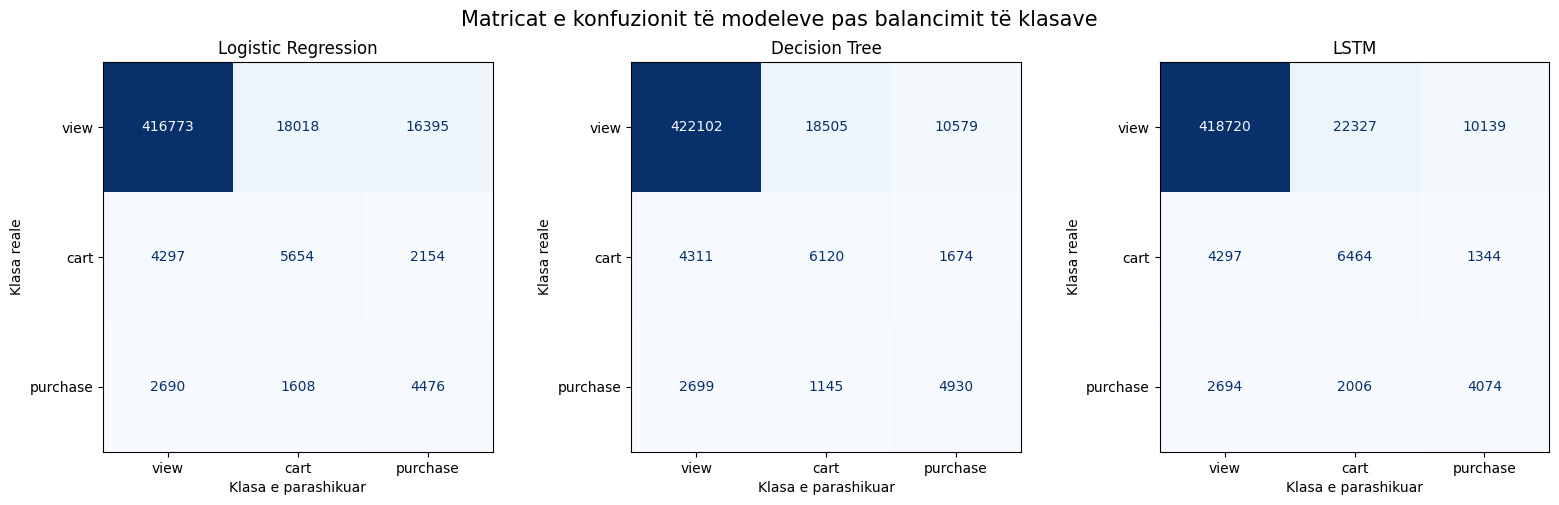

In [65]:
# ============================================================
# MATRICAT E KONFUZIONIT - PAS BALANCIMIT
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_cm_after = [
    ("Logistic Regression", cm_logistic_after),
    ("Decision Tree", cm_tree_after),
    ("LSTM", cm_lstm_after)
]

for ax, (model_name, cm) in zip(axes, models_cm_after):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["view", "cart", "purchase"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(model_name)
    ax.set_xlabel("Klasa e parashikuar")
    ax.set_ylabel("Klasa reale")

plt.suptitle(
    "Matricat e konfuzionit të modeleve pas balancimit të klasave",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "Figure_8_Confusion_Matrices_After_Balancing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
# ============================================================
# CLASSIFICATION REPORT - PAS BALANCIMIT
# ============================================================

reports_after = []

model_predictions_after = {
    "Logistic Regression": (
        y_test_traditional,
        y_pred_logistic_after
    ),
    "Decision Tree": (
        y_test_traditional,
        y_pred_tree_after
    ),
    "LSTM": (
        y_test_lstm_after,
        y_pred_lstm_after
    )
}

for model_name, (y_true, y_pred) in model_predictions_after.items():

    report = classification_report(
        y_true,
        y_pred,
        target_names=["view", "cart", "purchase"],
        output_dict=True,
        zero_division=0
    )

    for class_name in ["view", "cart", "purchase"]:

        reports_after.append({
            "Modeli": model_name,
            "Klasa": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1-Score": report[class_name]["f1-score"],
            "Support": int(report[class_name]["support"])
        })

classification_report_after_df = pd.DataFrame(
    reports_after
)

print("===== CLASSIFICATION REPORT - PAS BALANCIMIT =====")

display(
    classification_report_after_df.round({
        "Precision": 2,
        "Recall": 2,
        "F1-Score": 2
    })
)

===== CLASSIFICATION REPORT - PAS BALANCIMIT =====


,Modeli,Klasa,Precision,Recall,F1-Score,Support
0,Logistic Regression,view,0.98,0.92,0.95,451186
1,Logistic Regression,cart,0.22,0.47,0.30,12105
2,Logistic Regression,purchase,0.19,0.51,0.28,8774
3,Decision Tree,view,0.98,0.94,0.96,451186
4,Decision Tree,cart,0.24,0.51,0.32,12105
5,Decision Tree,purchase,0.29,0.56,0.38,8774
6,LSTM,view,0.98,0.93,0.96,451186
7,LSTM,cart,0.21,0.53,0.30,12105
8,LSTM,purchase,0.26,0.46,0.33,8774
